# Credit Default — Exploratory Data Analysis

UCI "Default of Credit Card Clients" (Taiwan, 30,000 records): predict whether a credit card client defaults on payment next month.

All 23 features describe information available **at decision time** (credit limit, demographics, 6 months of repayment status, bill amounts, and payment amounts). The target is resolved for every record — there are no unknown or pending outcomes.

Limitation: the dataset has **no timestamps**, so time-based (out-of-time) evaluation is not supported. This analysis and the follow-up model classify a single snapshot.

In [1]:
import sys
sys.path.insert(0, "../src")  # shared preprocessing module
import pandas as pd

df = pd.read_excel("../data/default_of_credit_card_clients.xls", header=1)
print(df.shape)
print("nulls:", int(df.isnull().sum().sum()))

(30000, 25)
nulls: 0


In [2]:
# Clean: rename target, drop ID, remap undefined category codes (see src/preprocessing.py)
from preprocessing import clean_frame, FEATURE_COLUMNS, TARGET
df = clean_frame(df)
print(df.shape)
print("features:", len(FEATURE_COLUMNS))
print("target column:", TARGET)

(30000, 24)
features: 23
target column: default


In [3]:
print("EDUCATION values:", sorted(df['EDUCATION'].unique()))
print("MARRIAGE values:", sorted(df['MARRIAGE'].unique()))

EDUCATION values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE values: [np.int64(1), np.int64(2), np.int64(3)]


## Target distribution

default rate: 0.2212 (6,636 of 30,000 clients)


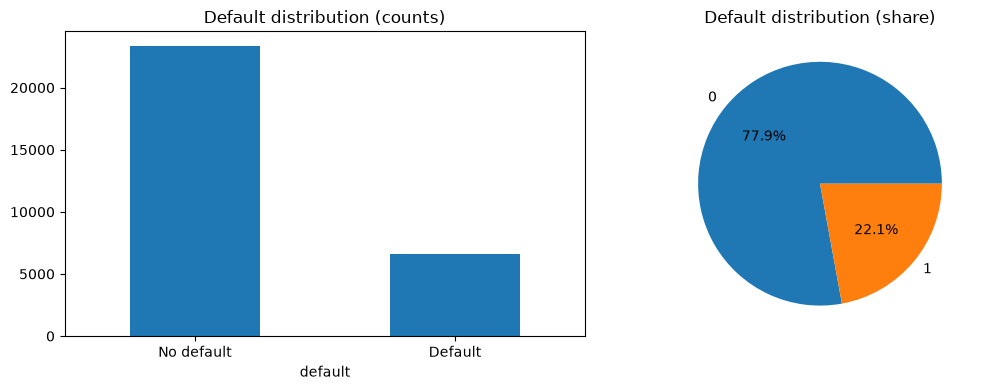

In [4]:
import matplotlib.pyplot as plt

rate = df[TARGET].mean()
print(f"default rate: {rate:.4f} ({int(df[TARGET].sum()):,} of {len(df):,} clients)")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].value_counts().plot(kind="bar", ax=ax[0])
ax[0].set_title("Default distribution (counts)")
ax[0].set_xticklabels(["No default", "Default"], rotation=0)
df[TARGET].value_counts().plot(kind="pie", autopct="%1.1f%%", ax=ax[1])
ax[1].set_title("Default distribution (share)")
ax[1].set_ylabel("")
plt.tight_layout()
plt.show()

## Segment default rates (with denominators)

In [5]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    ct = pd.crosstab(df[col], df[TARGET], normalize="index").round(4)
    ct["n"] = pd.crosstab(df[col], df[TARGET]).sum(axis=1)
    print(f"--- default rate by {col} ---")
    print(ct)
    print()

--- default rate by SEX ---
default       0       1      n
SEX                           
1        0.7583  0.2417  11888
2        0.7922  0.2078  18112

--- default rate by EDUCATION ---
default         0       1      n
EDUCATION                       
1          0.8077  0.1923  10585
2          0.7627  0.2373  14030
3          0.7484  0.2516   4917
4          0.9295  0.0705    468

--- default rate by MARRIAGE ---
default        0       1      n
MARRIAGE                       
1         0.7653  0.2347  13659
2         0.7907  0.2093  15964
3         0.7639  0.2361    377



In [6]:
# Repayment status of the most recent month (PAY_0) vs default rate
ct = pd.crosstab(df["PAY_0"], df[TARGET], normalize="index").round(4)
ct["n"] = pd.crosstab(df["PAY_0"], df[TARGET]).sum(axis=1)
print(ct)
print()
print("(-2 = no consumption, -1 = paid duly, 0 = revolving, 1..8 = months delayed)")

default       0       1      n
PAY_0                         
-2       0.8677  0.1323   2759
-1       0.8322  0.1678   5686
 0       0.8719  0.1281  14737
 1       0.6605  0.3395   3688
 2       0.3086  0.6914   2667
 3       0.2422  0.7578    322
 4       0.3158  0.6842     76
 5       0.5000  0.5000     26
 6       0.4545  0.5455     11
 7       0.2222  0.7778      9
 8       0.4211  0.5789     19

(-2 = no consumption, -1 = paid duly, 0 = revolving, 1..8 = months delayed)


## Distributions of key numeric features

/tmp/ipykernel_4578/986218424.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  for a in ax: a.set_xticklabels(["No default", "Default"])
/tmp/ipykernel_4578/986218424.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  for a in ax: a.set_xticklabels(["No default", "Default"])
/tmp/ipykernel_4578/986218424.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  for a in ax: a.set_xticklabels(["No default", "Default"])


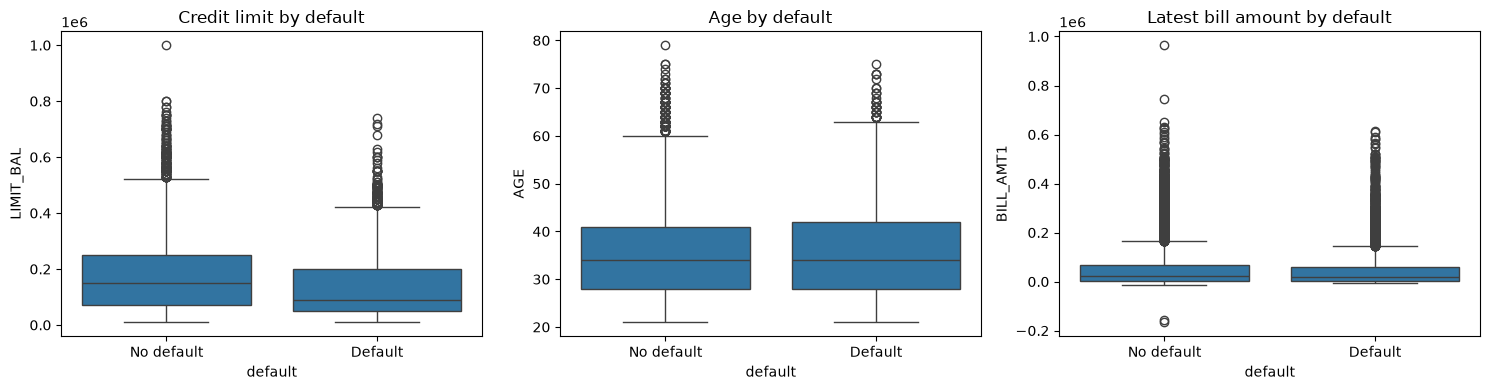

In [7]:
import seaborn as sns

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(x=TARGET, y="LIMIT_BAL", data=df, ax=ax[0]); ax[0].set_title("Credit limit by default")
sns.boxplot(x=TARGET, y="AGE", data=df, ax=ax[1]); ax[1].set_title("Age by default")
sns.boxplot(x=TARGET, y="BILL_AMT1", data=df, ax=ax[2]); ax[2].set_title("Latest bill amount by default")
for a in ax: a.set_xticklabels(["No default", "Default"])
plt.tight_layout()
plt.show()

## Correlations with the target (numeric features)

In [8]:
corr = df[FEATURE_COLUMNS + [TARGET]].corr(numeric_only=True)[TARGET].drop(TARGET)
print(corr.sort_values(ascending=False).round(3))
print()
print("PAY_* = repayment status per month (higher = longer delay);",
      "BILL_AMT* = statement bill; PAY_AMT* = amount actually paid.")

PAY_0        0.325
PAY_2        0.264
PAY_3        0.235
PAY_4        0.217
PAY_5        0.204
PAY_6        0.187
EDUCATION    0.034
AGE          0.014
BILL_AMT6   -0.005
BILL_AMT5   -0.007
BILL_AMT4   -0.010
BILL_AMT3   -0.014
BILL_AMT2   -0.014
BILL_AMT1   -0.020
MARRIAGE    -0.028
SEX         -0.040
PAY_AMT6    -0.053
PAY_AMT5    -0.055
PAY_AMT3    -0.056
PAY_AMT4    -0.057
PAY_AMT2    -0.059
PAY_AMT1    -0.073
LIMIT_BAL   -0.154
Name: default, dtype: float64

PAY_* = repayment status per month (higher = longer delay); BILL_AMT* = statement bill; PAY_AMT* = amount actually paid.


## Findings

- Default rate: 22.1% — imbalanced, but less severely than many churn datasets.
- Repayment status dominates the association ranking: recent payment delays (PAY_0..PAY_6) correlate most strongly with default. This is expected — past repayment behavior is the most informative signal available at decision time.
- Lower credit limits and younger age are associated with higher default rates, but weakly.
- Bill and payment amounts show modest associations; the *status* of repayment matters more than the amounts.
- Education/marriage/sex segments differ in default rates, but the gaps are small relative to repayment-status gaps.

## Notes

- Export the cleaned frame for modeling so the handoff is reproducible.

In [9]:
df.to_csv("../data/credit_default_clean.csv", index=False)
print("exported data/credit_default_clean.csv:", df.shape)

exported data/credit_default_clean.csv: (30000, 24)
